# Naija-Petro Dataset - Exploratory Data Analysis
## Deep-dive into 20K+ Synthetic Petroleum Engineering Instruction-Response Pairs

This notebook loads and thoroughly analyses the dataset produced by the NVIDIA Data Designer pipeline.

---
## 0. Setup

In [ ]:
!pip install -q pandas pyarrow matplotlib seaborn wordcloud jsonlines nltk textstat 2>/dev/null

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json, os, re, warnings
from pathlib import Path
from collections import Counter
from datetime import datetime

warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid", palette="deep", font_scale=1.1)
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['figure.dpi'] = 100

import nltk
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
nltk.download('stopwords', quiet=True)
from nltk.corpus import stopwords
STOP = set(stopwords.words('english'))

print("Libraries loaded")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 177.1/177.1 kB 8.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 27.8 MB/s eta 0:00:00
Libraries loaded


---
## 1. Load Data

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:


BASE = Path("/content/drive/MyDrive/petroleum_corpus")
PROCESSED = BASE / "processed"
AUGMENTED = BASE / "augmented"
METADATA  = BASE / "metadata"
P1_CKPT   = AUGMENTED / "checkpoints" / "pipeline1"
P2_CKPT   = AUGMENTED / "checkpoints" / "pipeline2"

# ── Load the main full dataset ──
full_path = PROCESSED / "final_full_dataset.parquet"
if full_path.exists():
    df = pd.read_parquet(full_path)
    print(f"Loaded full dataset: {len(df):,} rows")
else:
    # Fallback: load from checkpoints
    dfs = []
    for d in [P1_CKPT, P2_CKPT]:
        if d.exists():
            for f in sorted(d.glob("batch_*.parquet")):
                dfs.append(pd.read_parquet(f))
    df = pd.concat(dfs, ignore_index=True) if dfs else pd.DataFrame()
    print(f"Loaded from checkpoints: {len(df):,} rows")

# ── Also load Alpaca format ──
alpaca_path = PROCESSED / "final_alpaca_format.jsonl"
if alpaca_path.exists():
    import jsonlines
    with jsonlines.open(alpaca_path) as r:
        alpaca = list(r)
    print(f"Alpaca JSONL: {len(alpaca):,} records")

# ── Load quality scores if available ──
scored_path = AUGMENTED / "quality_scored_sample.parquet"
try:
    df_scored = pd.read_parquet(scored_path) if scored_path.exists() else pd.DataFrame()
    if len(df_scored): print(f"Quality scores: {len(df_scored):,} scored samples")
except Exception as e:
    print(f"Quality scores file has nested structs, loading with pyarrow...")
    try:
        import pyarrow.parquet as pq
        table = pq.read_table(scored_path)
        # Flatten nested struct columns
        flat_cols = {}
        for col_name in table.column_names:
            col = table.column(col_name)
            if hasattr(col.type, 'num_fields') and col.type.num_fields > 0:
                # It's a struct — flatten each sub-field
                for i in range(col.type.num_fields):
                    field_name = col.type.field(i).name
                    sub_col = col.combine_chunks().field(field_name)
                    if hasattr(sub_col.type, 'num_fields') and sub_col.type.num_fields > 0:
                        for j in range(sub_col.type.num_fields):
                            sub_field = sub_col.type.field(j).name
                            flat_cols[f"{col_name}_{field_name}_{sub_field}"] = sub_col.field(sub_field).to_pylist()
                    else:
                        flat_cols[f"{col_name}_{field_name}"] = sub_col.to_pylist()
            else:
                flat_cols[col_name] = col.to_pylist()
        df_scored = pd.DataFrame(flat_cols)
        print(f"Quality scores loaded (flattened): {len(df_scored):,} rows, {list(df_scored.columns)}")
    except Exception as e2:
        print(f"Could not load quality scores: {e2}")
        df_scored = pd.DataFrame()

# ── Load seed corpus ──
seed_path = PROCESSED / "seed_corpus.parquet"
df_seed = pd.read_parquet(seed_path) if seed_path.exists() else pd.DataFrame()
if len(df_seed): print(f"Seed corpus: {len(df_seed):,} chunks")

# ── Load metadata ──
stats_path = METADATA / "final_statistics.json"
if stats_path.exists():
    with open(stats_path) as f:
        final_stats = json.load(f)
    print(f"\nFinal stats from pipeline:")
    for k, v in final_stats.items():
        if not isinstance(v, dict):
            print(f"  {k}: {v}")

print(f"\nDataset shape: {df.shape}")
print(f"Columns: {list(df.columns)}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Loaded full dataset: 33,859 rows
Alpaca JSONL: 33,859 records
Quality scores file has nested structs, loading with pyarrow...
Quality scores loaded (flattened): 500 rows, ['instruction', 'response', 'instruction_category', 'source_type', 'pipeline', 'quality_score_completeness_reasoning', 'quality_score_completeness_score', 'quality_score_technical_accuracy_reasoning', 'quality_score_technical_accuracy_score', 'quality_score_usefulness_reasoning', 'quality_score_usefulness_score']
Seed corpus: 66,905 chunks

Final stats from pipeline:
  total_instruction_response_pairs: 33859
  total_instruction_words: 1569908
  total_response_words: 12347947
  avg_instruction_words: 46
  avg_response_words: 364
  generated_at: 2026-03-18T13:07:42.306835
  generated_with: NVIDIA NeMo Data Designer v2 (batched)

Dataset shape: (33859, 11)
Columns: ['instruction_category', 'com

---
## 2. Basic Overview

In [ ]:
# Shape and types
print("COLUMN INFO")
print("=" * 70)
for col in df.columns:
    dtype = df[col].dtype
    non_null = df[col].notna().sum()
    nunique = df[col].nunique()
    sample = str(df[col].dropna().iloc[0])[:60] if non_null > 0 else "N/A"
    print(f"  {col:30s}  {str(dtype):10s}  {non_null:>6,} non-null  {nunique:>6,} unique  | {sample}...")

print(f"\nNull counts:")
nulls = df.isnull().sum()
for col in nulls[nulls > 0].index:
    print(f"  {col}: {nulls[col]:,} ({100*nulls[col]/len(df):.1f}%)")
if nulls.sum() == 0:
    print("  None! Dataset is complete.")

print(f"\nDuplicate instructions: {df['instruction'].duplicated().sum():,}")
print(f"Duplicate responses:    {df['response'].duplicated().sum():,}")

COLUMN INFO
  instruction_category            string      14,745 non-null      10 unique  | troubleshooting...
  complexity_level                string      14,745 non-null       4 unique  | intermediate...
  subdomain                       string      14,745 non-null      12 unique  | offshore_subsea...
  instruction                     string      33,859 non-null  33,859 unique  | During a subsea production run, the subsea pressure gauge on...
  response                        string      33,859 non-null  33,859 unique  | **Step‑by‑step troubleshooting methodology**

1. **Verify th...
  text                            string      19,114 non-null  16,704 unique  | i��$��� z�&�S�L�#� Q��h�}F���|Ƅ)n��G��O=��>�>�2��q2� }A�x@� ...
  title                           string      19,114 non-null  14,981 unique  | ...
  source                          string      19,114 non-null      16 unique  | eia...
  content_type                    string      19,114 non-null       8 unique  | government_

In [ ]:
# First 3 samples
for i in range(min(3, len(df))):
    row = df.iloc[i]
    print(f"{'='*70}")
    print(f"SAMPLE {i+1}")
    print(f"{'='*70}")
    for col in df.columns:
        val = str(row[col])
        if len(val) > 200:
            val = val[:200] + "..."
        print(f"  {col}: {val}")
    print()

SAMPLE 1
  instruction_category: troubleshooting
  complexity_level: intermediate
  subdomain: offshore_subsea
  instruction: During a subsea production run, the subsea pressure gauge on a 7‑inch riser at 1500 m water depth suddenly drops from 2500 psi to 1500 psi while the flow rate remains unchanged, triggering a wellhead ...
  response: **Step‑by‑step troubleshooting methodology**

1. **Verify the alarm and capture raw data**  
   - Pull the alarm log from the subsea control system (SCS) and note the timestamp, pressure‑gauge ID, and...
  text: <NA>
  title: <NA>
  source: <NA>
  content_type: <NA>
  word_count: <NA>
  qa_style: <NA>

SAMPLE 2
  instruction_category: safety_compliance
  complexity_level: intermediate
  subdomain: enhanced_oil_recovery
  instruction: During an offshore enhanced oil recovery project employing nitrogen gas lift to increase reservoir pressure, the wellhead pressure sensor records a rapid rise to 120 MPa while the nitrogen supply pres...
  response: **Co

---
## 3. Text Length Analysis

In [ ]:
# Compute text metrics
df['instr_chars'] = df['instruction'].str.len()
df['instr_words'] = df['instruction'].str.split().str.len()
df['resp_chars']  = df['response'].str.len()
df['resp_words']  = df['response'].str.split().str.len()
df['instr_sentences'] = df['instruction'].apply(lambda x: len(re.split(r'[.!?]+', str(x))))
df['resp_sentences']  = df['response'].apply(lambda x: len(re.split(r'[.!?]+', str(x))))
df['resp_to_instr_ratio'] = df['resp_words'] / df['instr_words'].clip(lower=1)

print("TEXT LENGTH STATISTICS")
print("=" * 70)
for col, label in [('instr_words','Instruction words'), ('resp_words','Response words'),
                    ('instr_chars','Instruction chars'), ('resp_chars','Response chars'),
                    ('resp_to_instr_ratio','Response/Instruction ratio')]:
    s = df[col]
    print(f"  {label:30s}  mean={s.mean():.0f}  median={s.median():.0f}  "
          f"std={s.std():.0f}  min={s.min():.0f}  max={s.max():.0f}")

print(f"\n  Total instruction words: {df['instr_words'].sum():,}")
print(f"  Total response words:    {df['resp_words'].sum():,}")
print(f"  Total words (all):       {df['instr_words'].sum() + df['resp_words'].sum():,}")

TEXT LENGTH STATISTICS
  Instruction words               mean=46  median=40  std=25  min=3  max=307
  Response words                  mean=365  median=372  std=133  min=5  max=831
  Instruction chars               mean=326  median=293  std=170  min=22  max=2061
  Response chars                  mean=2596  median=2634  std=991  min=52  max=5093
  Response/Instruction ratio      mean=11  median=9  std=7  min=0  max=92

  Total instruction words: 1,569,908
  Total response words:    12,347,947
  Total words (all):       13,917,855


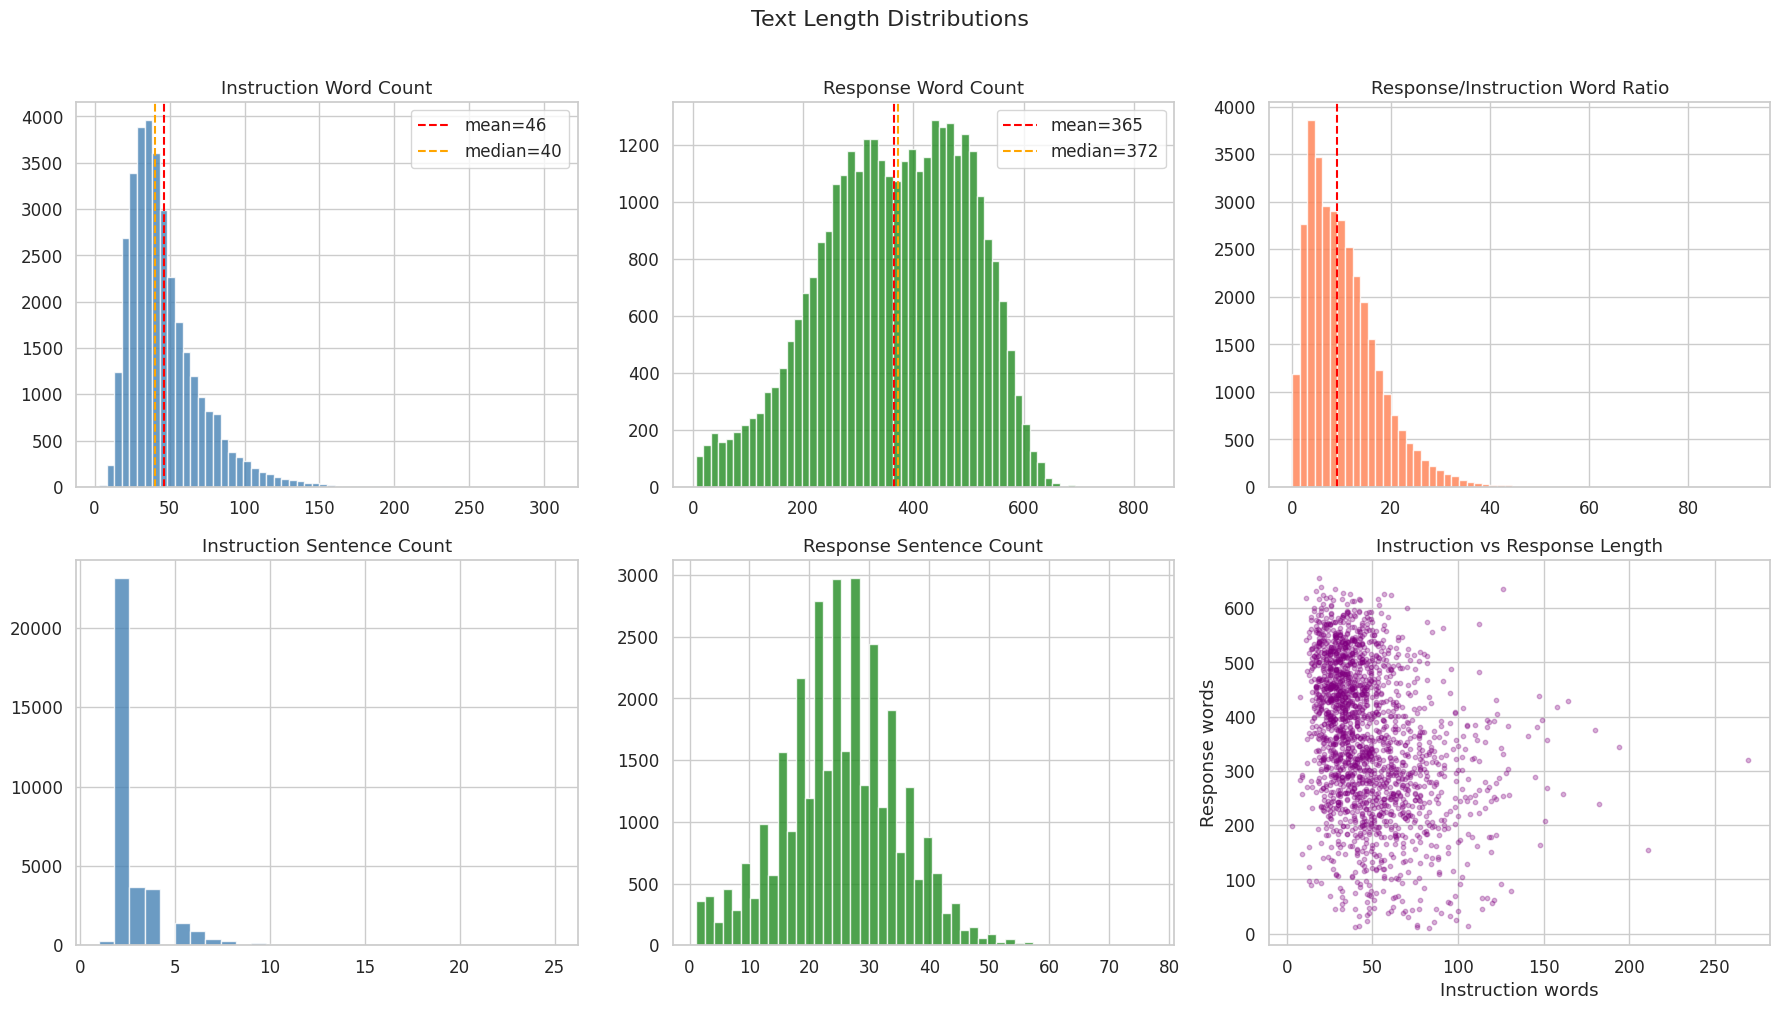

In [ ]:
# Distribution plots
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

axes[0,0].hist(df['instr_words'], bins=60, color='steelblue', edgecolor='white', alpha=0.8)
axes[0,0].axvline(df['instr_words'].mean(), color='red', ls='--', label=f"mean={df['instr_words'].mean():.0f}")
axes[0,0].axvline(df['instr_words'].median(), color='orange', ls='--', label=f"median={df['instr_words'].median():.0f}")
axes[0,0].set_title('Instruction Word Count'); axes[0,0].legend()

axes[0,1].hist(df['resp_words'], bins=60, color='forestgreen', edgecolor='white', alpha=0.8)
axes[0,1].axvline(df['resp_words'].mean(), color='red', ls='--', label=f"mean={df['resp_words'].mean():.0f}")
axes[0,1].axvline(df['resp_words'].median(), color='orange', ls='--', label=f"median={df['resp_words'].median():.0f}")
axes[0,1].set_title('Response Word Count'); axes[0,1].legend()

axes[0,2].hist(df['resp_to_instr_ratio'], bins=60, color='coral', edgecolor='white', alpha=0.8)
axes[0,2].set_title('Response/Instruction Word Ratio')
axes[0,2].axvline(df['resp_to_instr_ratio'].median(), color='red', ls='--')

axes[1,0].hist(df['instr_sentences'], bins=30, color='steelblue', edgecolor='white', alpha=0.8)
axes[1,0].set_title('Instruction Sentence Count')

axes[1,1].hist(df['resp_sentences'], bins=50, color='forestgreen', edgecolor='white', alpha=0.8)
axes[1,1].set_title('Response Sentence Count')

# Scatter: instruction length vs response length
sample_idx = np.random.choice(len(df), min(2000, len(df)), replace=False)
axes[1,2].scatter(df.iloc[sample_idx]['instr_words'], df.iloc[sample_idx]['resp_words'],
                  alpha=0.3, s=10, color='purple')
axes[1,2].set_xlabel('Instruction words'); axes[1,2].set_ylabel('Response words')
axes[1,2].set_title('Instruction vs Response Length')

plt.suptitle('Text Length Distributions', fontsize=16, y=1.01)
plt.tight_layout(); plt.show()

---
## 4. Categorical Distributions (Pipeline, Category, Subdomain)

Categorical columns found: ['instruction_category', 'complexity_level', 'subdomain', 'qa_style', 'content_type']


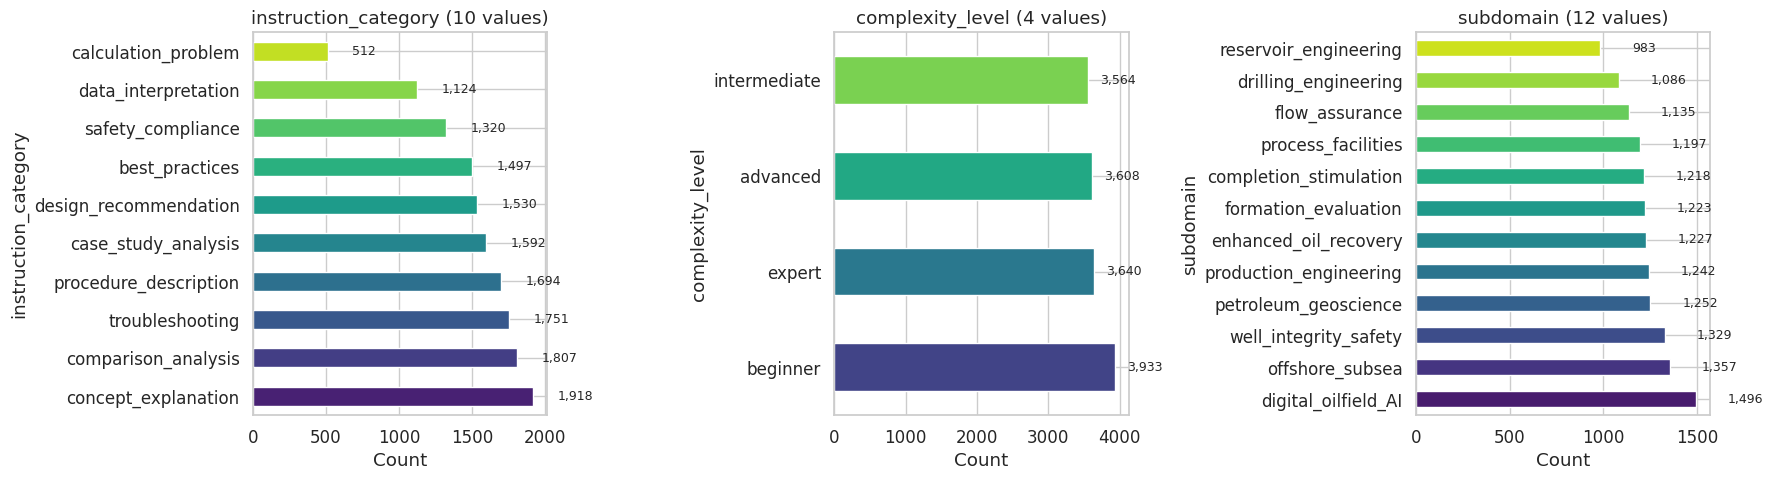

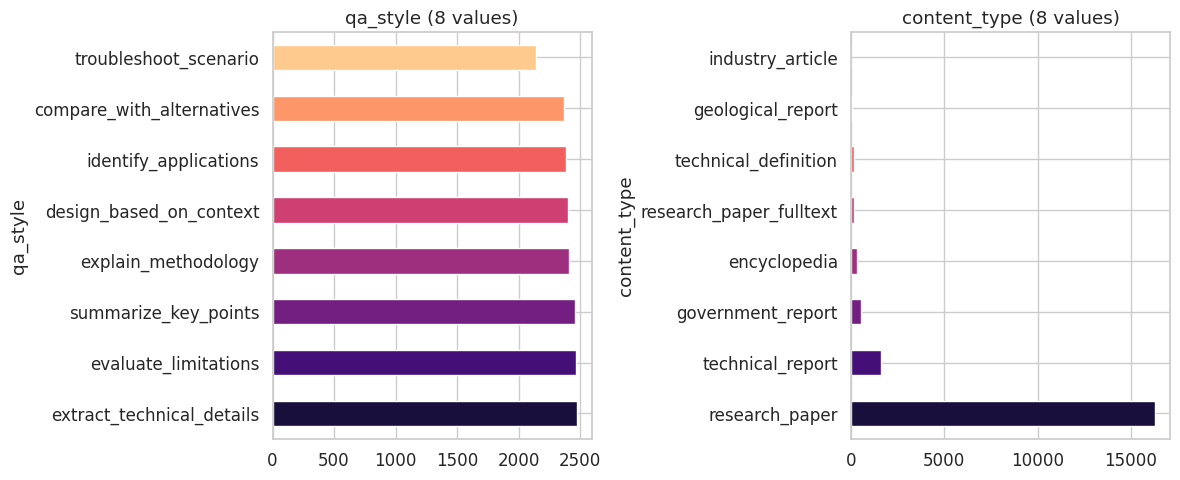


instruction_category:
  concept_explanation                       1,918  (5.7%)
  comparison_analysis                       1,807  (5.3%)
  troubleshooting                           1,751  (5.2%)
  procedure_description                     1,694  (5.0%)
  case_study_analysis                       1,592  (4.7%)
  design_recommendation                     1,530  (4.5%)
  best_practices                            1,497  (4.4%)
  safety_compliance                         1,320  (3.9%)
  data_interpretation                       1,124  (3.3%)
  calculation_problem                         512  (1.5%)

complexity_level:
  beginner                                  3,933  (11.6%)
  expert                                    3,640  (10.8%)
  advanced                                  3,608  (10.7%)
  intermediate                              3,564  (10.5%)

subdomain:
  digital_oilfield_AI                       1,496  (4.4%)
  offshore_subsea                           1,357  (4.0%)
  well_integri

In [ ]:
cat_cols = [c for c in ['pipeline','instruction_category','complexity_level','subdomain',
            'source_type','qa_style','content_type'] if c in df.columns and df[c].notna().any()]

print(f"Categorical columns found: {cat_cols}")

n = len(cat_cols)
if n > 0:
    fig, axes = plt.subplots(1, min(n, 3), figsize=(6*min(n,3), 5))
    if n == 1: axes = [axes]

    for i, col in enumerate(cat_cols[:3]):
        ax = axes[i] if n > 1 else axes[0]
        vc = df[col].value_counts()
        vc.plot.barh(ax=ax, color=sns.color_palette("viridis", len(vc)))
        ax.set_title(f'{col} ({len(vc)} values)')
        ax.set_xlabel('Count')
        for j, v in enumerate(vc.values):
            ax.text(v + len(df)*0.005, j, f'{v:,}', va='center', fontsize=9)
    plt.tight_layout(); plt.show()

    # If more than 3 categorical cols, plot the rest
    if n > 3:
        fig, axes = plt.subplots(1, min(n-3, 3), figsize=(6*min(n-3,3), 5))
        if n-3 == 1: axes = [axes]
        for i, col in enumerate(cat_cols[3:6]):
            ax = axes[i] if n-3 > 1 else axes[0]
            vc = df[col].value_counts()
            vc.plot.barh(ax=ax, color=sns.color_palette("magma", len(vc)))
            ax.set_title(f'{col} ({len(vc)} values)')
        plt.tight_layout(); plt.show()

# Print all value counts
for col in cat_cols:
    print(f"\n{col}:")
    for val, cnt in df[col].value_counts().items():
        print(f"  {val:40s} {cnt:>6,}  ({100*cnt/len(df):.1f}%)")

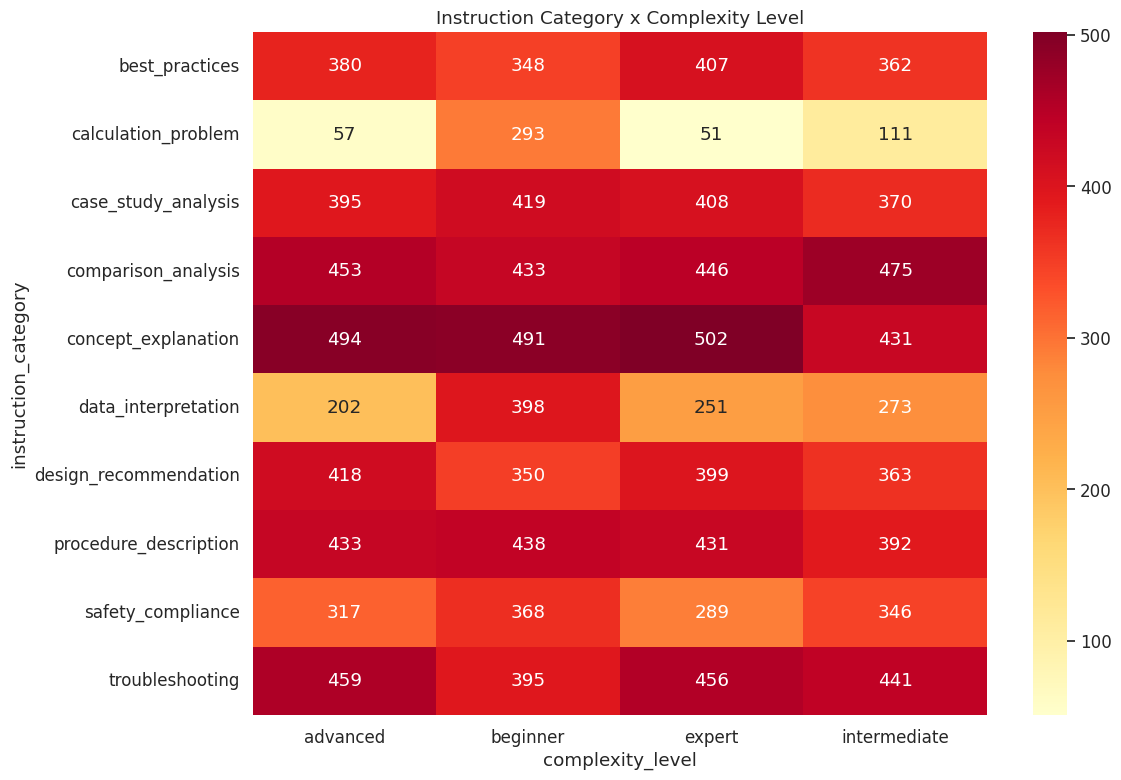

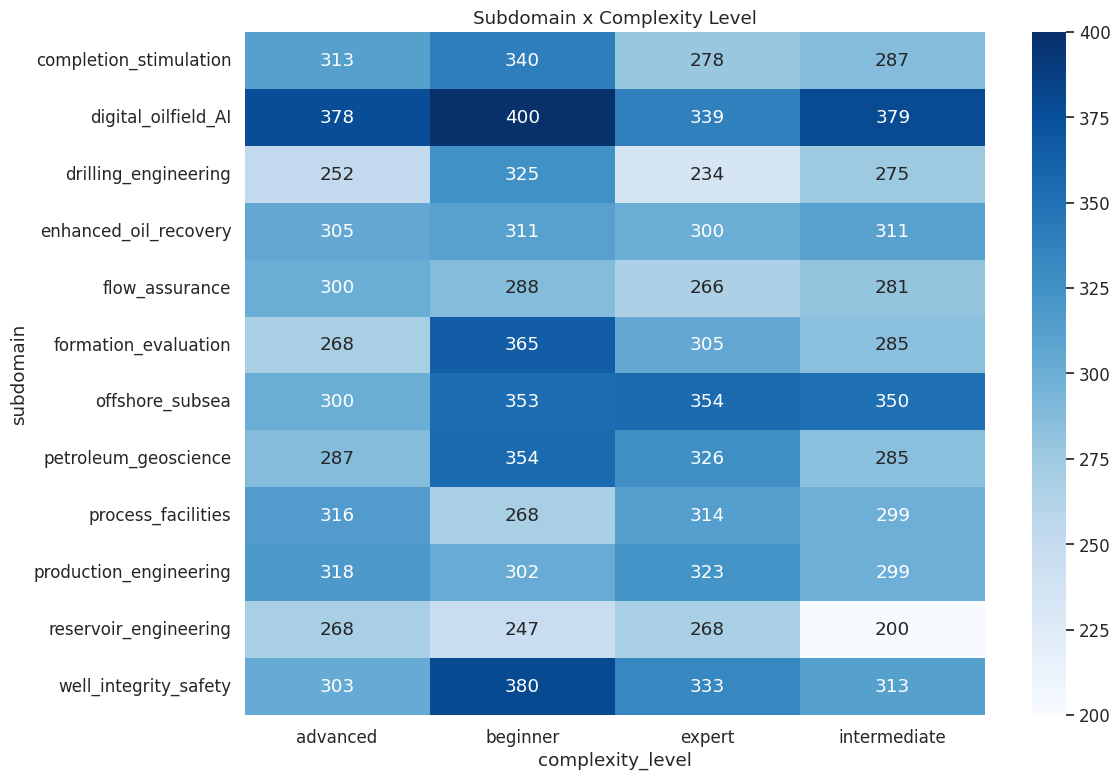

In [ ]:
# Cross-tab: category x complexity (if both exist)
if 'instruction_category' in df.columns and 'complexity_level' in df.columns:
    ct = pd.crosstab(df['instruction_category'], df['complexity_level'])
    if len(ct) > 0:
        fig, ax = plt.subplots(figsize=(12, 8))
        sns.heatmap(ct, annot=True, fmt='d', cmap='YlOrRd', ax=ax)
        ax.set_title('Instruction Category x Complexity Level')
        plt.tight_layout(); plt.show()

if 'subdomain' in df.columns and 'complexity_level' in df.columns:
    ct2 = pd.crosstab(df['subdomain'], df['complexity_level'])
    if len(ct2) > 0:
        fig, ax = plt.subplots(figsize=(12, 8))
        sns.heatmap(ct2, annot=True, fmt='d', cmap='Blues', ax=ax)
        ax.set_title('Subdomain x Complexity Level')
        plt.tight_layout(); plt.show()

---
## 5. Word Frequency & Domain Vocabulary

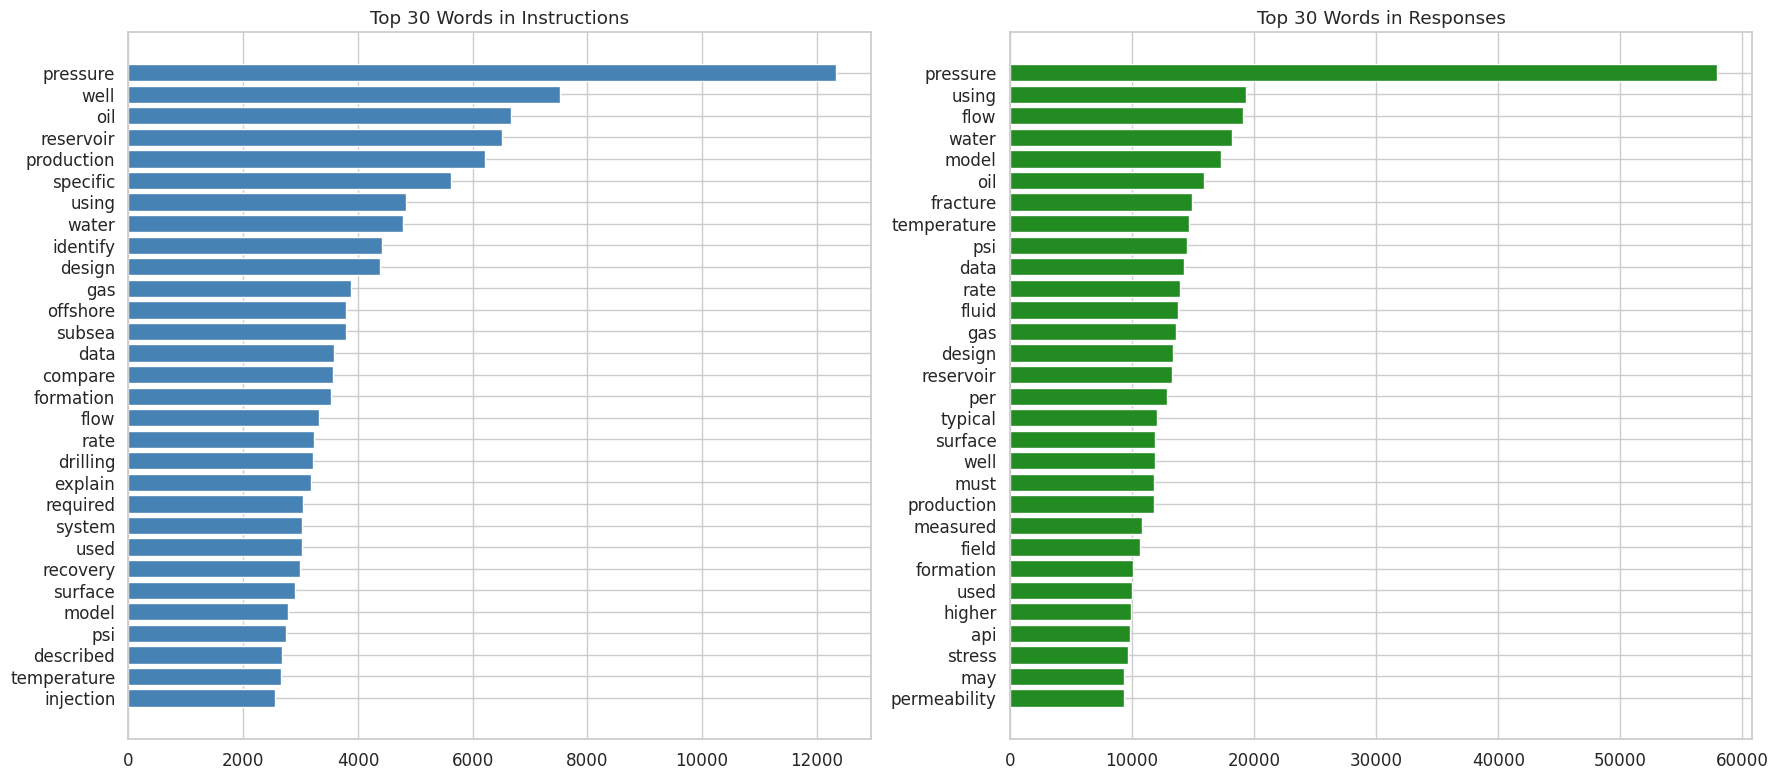

In [ ]:
# Top words in instructions vs responses (excluding stopwords)
def get_top_words(series, n=40):
    words = ' '.join(series.dropna().astype(str)).lower().split()
    words = [w for w in words if w.isalpha() and len(w) > 2 and w not in STOP]
    return Counter(words).most_common(n)

top_instr = get_top_words(df['instruction'])
top_resp  = get_top_words(df['response'])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 8))

words_i, counts_i = zip(*top_instr[:30])
ax1.barh(range(len(words_i)), counts_i, color='steelblue')
ax1.set_yticks(range(len(words_i))); ax1.set_yticklabels(words_i)
ax1.invert_yaxis(); ax1.set_title('Top 30 Words in Instructions')

words_r, counts_r = zip(*top_resp[:30])
ax2.barh(range(len(words_r)), counts_r, color='forestgreen')
ax2.set_yticks(range(len(words_r))); ax2.set_yticklabels(words_r)
ax2.invert_yaxis(); ax2.set_title('Top 30 Words in Responses')

plt.tight_layout(); plt.show()

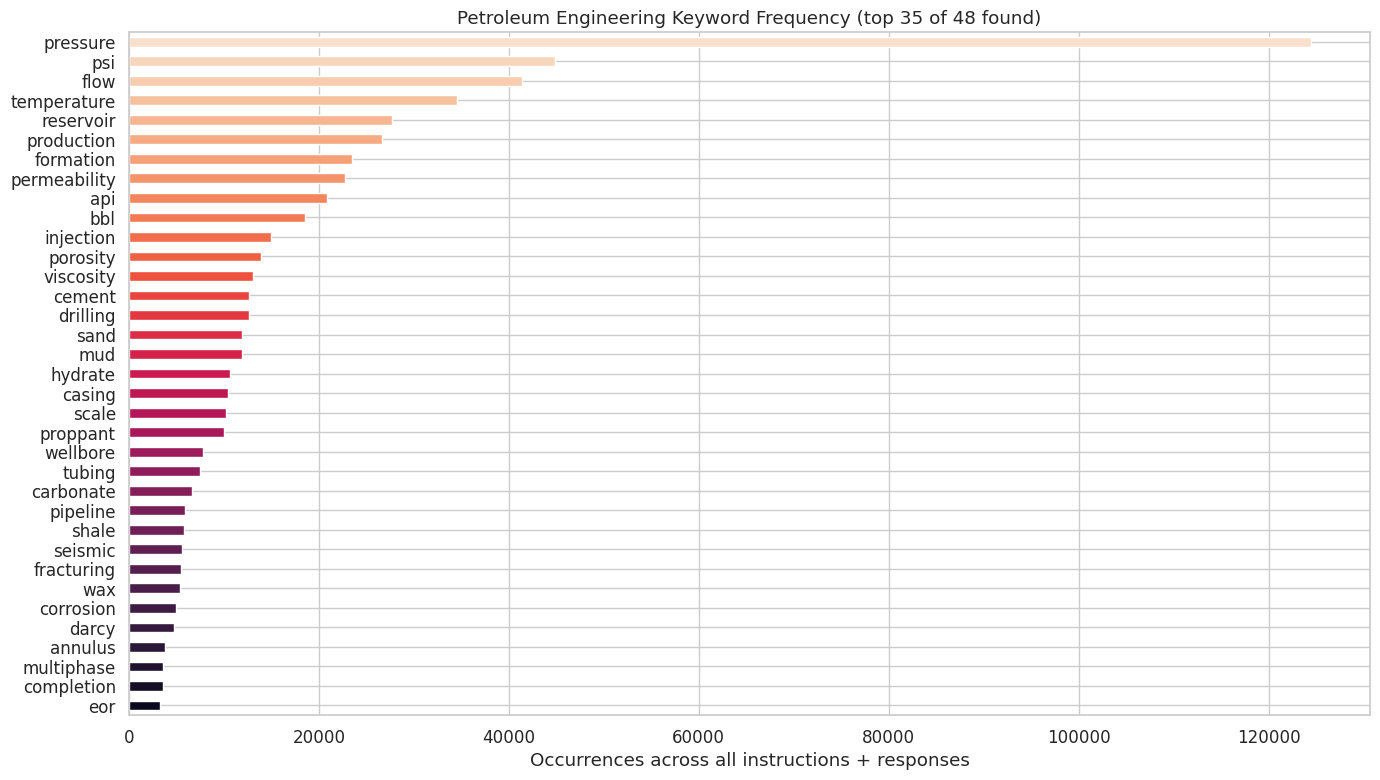

Keywords found: 48/48
Total keyword mentions: 607,971


In [ ]:
# Petroleum engineering domain keywords frequency
PETRO_KEYWORDS = [
    'reservoir', 'permeability', 'porosity', 'wellbore', 'drilling',
    'casing', 'cement', 'fracturing', 'proppant', 'viscosity',
    'pressure', 'temperature', 'flow', 'production', 'injection',
    'completion', 'stimulation', 'acidizing', 'eor', 'waterflooding',
    'darcy', 'bbl', 'psi', 'api', 'formation', 'sand', 'shale',
    'carbonate', 'tubing', 'annulus', 'blowout', 'mud', 'bop',
    'workover', 'wireline', 'logging', 'seismic', 'geomechanics',
    'multiphase', 'separator', 'dehydration', 'corrosion', 'scale',
    'wax', 'asphaltene', 'hydrate', 'pipeline', 'compressor',
]

all_text = (df['instruction'] + ' ' + df['response']).str.lower()
keyword_counts = {}
for kw in PETRO_KEYWORDS:
    keyword_counts[kw] = all_text.str.count(r'\b' + kw + r'\b').sum()

kw_df = pd.Series(keyword_counts).sort_values(ascending=False)
kw_present = kw_df[kw_df > 0]

fig, ax = plt.subplots(figsize=(14, 8))
kw_present[:35].plot.barh(ax=ax, color=sns.color_palette("rocket_r", len(kw_present[:35])))
ax.set_title(f'Petroleum Engineering Keyword Frequency (top 35 of {len(kw_present)} found)')
ax.set_xlabel('Occurrences across all instructions + responses')
ax.invert_yaxis()
plt.tight_layout(); plt.show()

print(f"Keywords found: {len(kw_present)}/{len(PETRO_KEYWORDS)}")
print(f"Total keyword mentions: {kw_present.sum():,}")
missing = [k for k in PETRO_KEYWORDS if keyword_counts[k] == 0]
if missing: print(f"Keywords NOT found: {missing}")

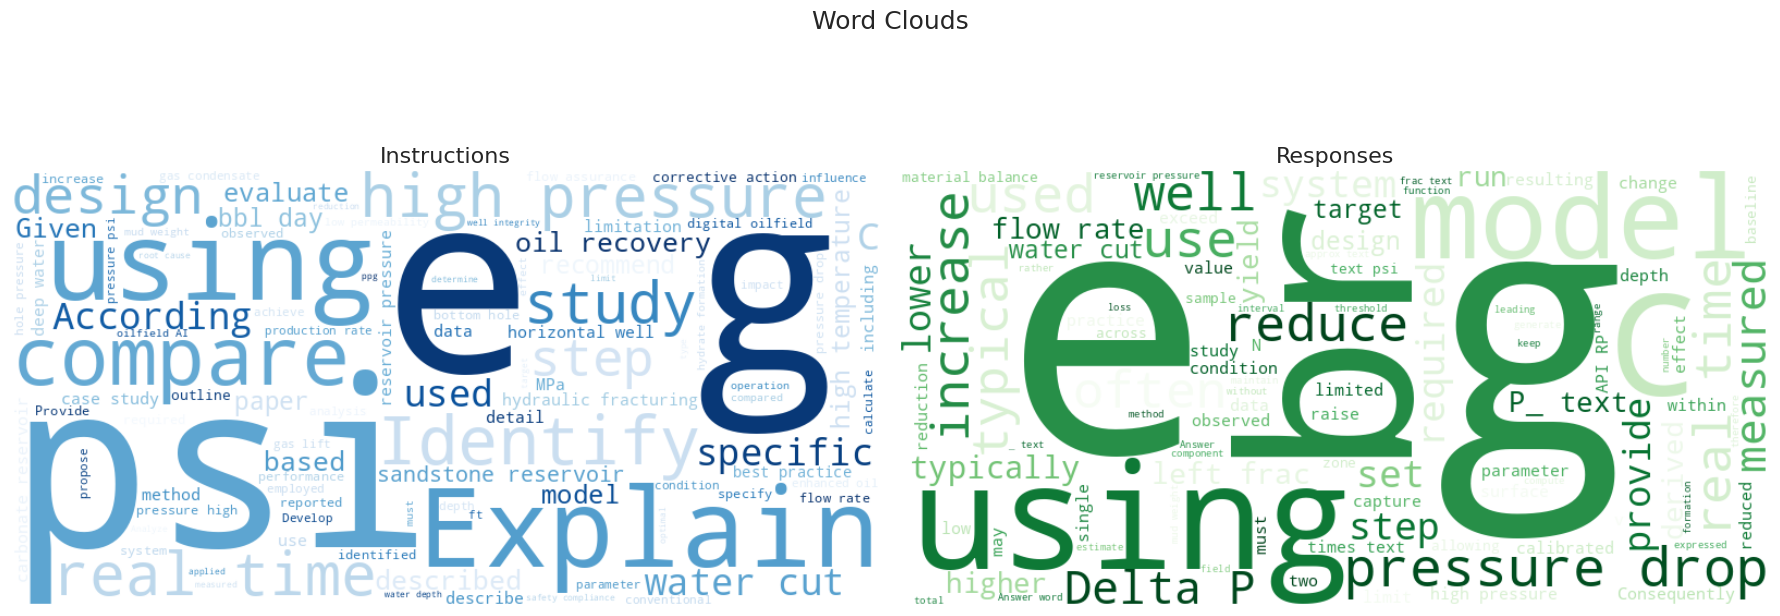

In [ ]:
# Word clouds
from wordcloud import WordCloud

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))

wc1 = WordCloud(width=800, height=400, background_color='white', colormap='Blues',
                stopwords=STOP, max_words=100).generate(' '.join(df['instruction'].dropna()))
ax1.imshow(wc1, interpolation='bilinear'); ax1.axis('off'); ax1.set_title('Instructions', fontsize=16)

wc2 = WordCloud(width=800, height=400, background_color='white', colormap='Greens',
                stopwords=STOP, max_words=100).generate(' '.join(df['response'].dropna()))
ax2.imshow(wc2, interpolation='bilinear'); ax2.axis('off'); ax2.set_title('Responses', fontsize=16)

plt.suptitle('Word Clouds', fontsize=18, y=1.01)
plt.tight_layout(); plt.show()

---
## 6. Response Quality Indicators

In [ ]:
# Structural quality checks
df['resp_has_equation'] = df['response'].str.contains(r'[=><].*\d', regex=True, na=False)
df['resp_has_units'] = df['response'].str.contains(r'\b(psi|bbl|ft|md|cp|stb|scf|bopd|mscf|darcy|mpa|kpa)\b', case=False, regex=True, na=False)
df['resp_has_numbers'] = df['response'].str.contains(r'\d+\.?\d*', regex=True, na=False)
df['resp_has_bullets'] = df['response'].str.contains(r'(^\s*[-•\d]+[.)])', regex=True, na=False)
df['instr_is_question'] = df['instruction'].str.strip().str.endswith('?')

# Token estimation (rough: 1 token ~ 0.75 words)
df['est_tokens'] = ((df['instr_words'] + df['resp_words']) / 0.75).astype(int)

quality_metrics = {
    'Has equations/formulas': df['resp_has_equation'].mean(),
    'Has engineering units': df['resp_has_units'].mean(),
    'Has numeric values': df['resp_has_numbers'].mean(),
    'Has bullet/numbered lists': df['resp_has_bullets'].mean(),
    'Instruction is a question': df['instr_is_question'].mean(),
}

print("RESPONSE QUALITY INDICATORS")
print("=" * 50)
for metric, val in quality_metrics.items():
    bar = '#' * int(val * 40)
    print(f"  {metric:35s} {100*val:5.1f}%  {bar}")

print(f"\nEstimated total tokens: {df['est_tokens'].sum():,}")
print(f"Avg tokens per sample:  {df['est_tokens'].mean():.0f}")

RESPONSE QUALITY INDICATORS
  Has equations/formulas               82.5%  #################################
  Has engineering units                52.6%  #####################
  Has numeric values                   99.4%  #######################################
  Has bullet/numbered lists             0.0%  
  Instruction is a question            45.7%  ##################

Estimated total tokens: 18,545,945
Avg tokens per sample:  548


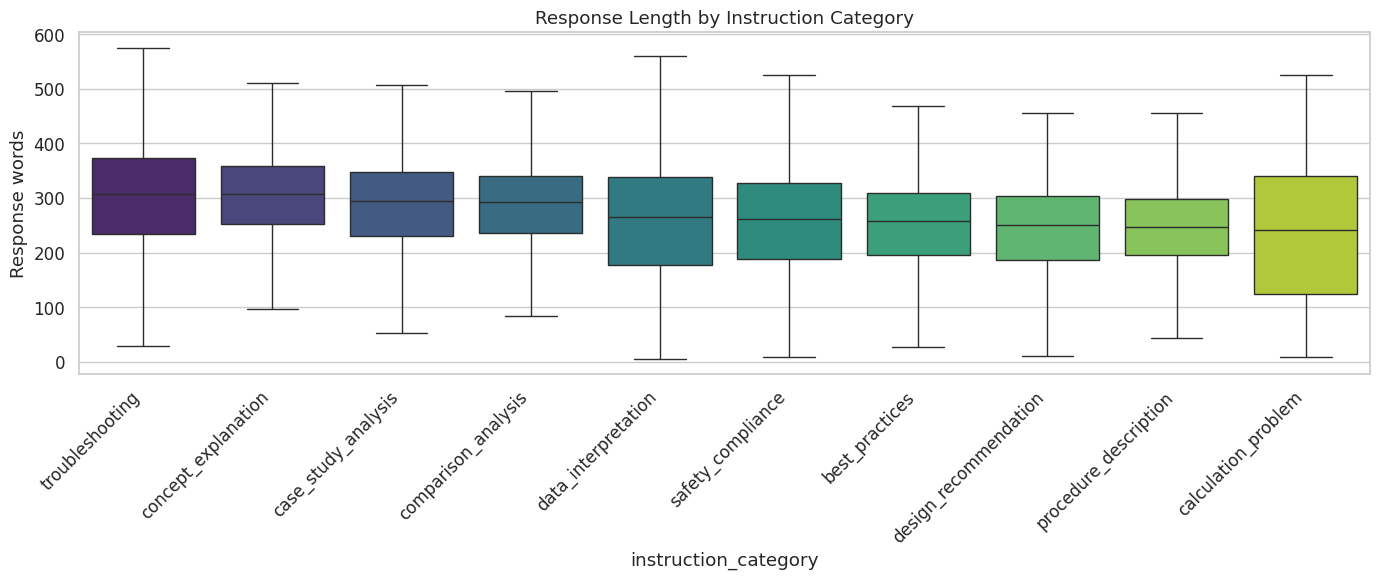

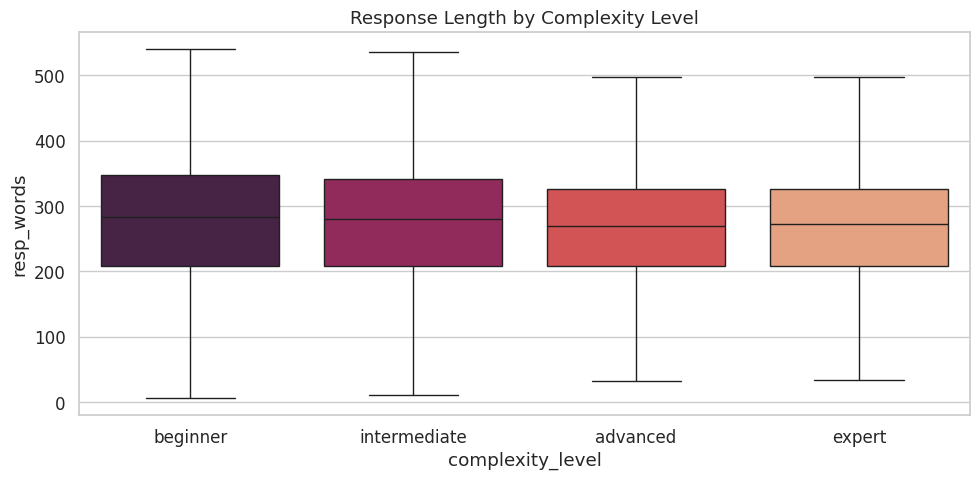

In [ ]:
# Response length by category (if available)
if 'instruction_category' in df.columns:
    fig, ax = plt.subplots(figsize=(14, 6))
    order = df.groupby('instruction_category')['resp_words'].median().sort_values(ascending=False).index
    sns.boxplot(data=df, x='instruction_category', y='resp_words', order=order, ax=ax,
                palette='viridis', showfliers=False)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
    ax.set_title('Response Length by Instruction Category')
    ax.set_ylabel('Response words')
    plt.tight_layout(); plt.show()

if 'complexity_level' in df.columns:
    fig, ax = plt.subplots(figsize=(10, 5))
    order_c = ['beginner','intermediate','advanced','expert']
    order_c = [c for c in order_c if c in df['complexity_level'].values]
    sns.boxplot(data=df, x='complexity_level', y='resp_words', order=order_c, ax=ax,
                palette='rocket', showfliers=False)
    ax.set_title('Response Length by Complexity Level')
    plt.tight_layout(); plt.show()

---
## 7. Quality Scores Analysis (if available)

In [ ]:
if len(df_scored) > 0:
    score_cols = [c for c in df_scored.columns if 'quality_score' in c and df_scored[c].dtype in ['int64','float64']]
    if not score_cols:
        for c in ['quality_score_technical_accuracy','quality_score_completeness','quality_score_usefulness']:
            if c in df_scored.columns:
                df_scored[c] = pd.to_numeric(df_scored[c], errors='coerce')
                score_cols.append(c)

    if score_cols:
        df_scored['composite'] = df_scored[score_cols].mean(axis=1)

        print("QUALITY SCORE SUMMARY")
        print("=" * 60)
        for c in score_cols + ['composite']:
            s = df_scored[c].dropna()
            print(f"  {c:45s}  mean={s.mean():.2f}  std={s.std():.2f}  median={s.median():.1f}")

        fig, axes = plt.subplots(1, len(score_cols)+1, figsize=(5*(len(score_cols)+1), 4))
        for i, c in enumerate(score_cols + ['composite']):
            axes[i].hist(df_scored[c].dropna(), bins=20, color=sns.color_palette()[i], edgecolor='white')
            axes[i].axvline(df_scored[c].mean(), color='red', ls='--')
            axes[i].set_title(c.replace('quality_score_','').replace('_',' ').title())
        plt.suptitle('Quality Score Distributions', fontsize=14)
        plt.tight_layout(); plt.show()

        # Score tier breakdown
        tiers = pd.cut(df_scored['composite'], bins=[-0.1,1,2,3,4.01],
                       labels=['Poor (0-1)','Low (1-2)','Good (2-3)','Excellent (3-4)'])
        print("\nQuality Tiers:")
        for tier, cnt in tiers.value_counts().sort_index().items():
            print(f"  {tier:20s} {cnt:>5,}  ({100*cnt/len(df_scored):.1f}%)")
    else:
        print("Score columns not found in expected format.")
else:
    print("No quality scores available. Skipping this section.")

Score columns not found in expected format.


---
## 8. Seed Corpus Analysis

SEED CORPUS OVERVIEW
  Total chunks: 66,905
  Columns: ['text', 'title', 'source', 'content_type', 'word_count']
  Total words: 20,519,557
  Avg chunk:   307 words


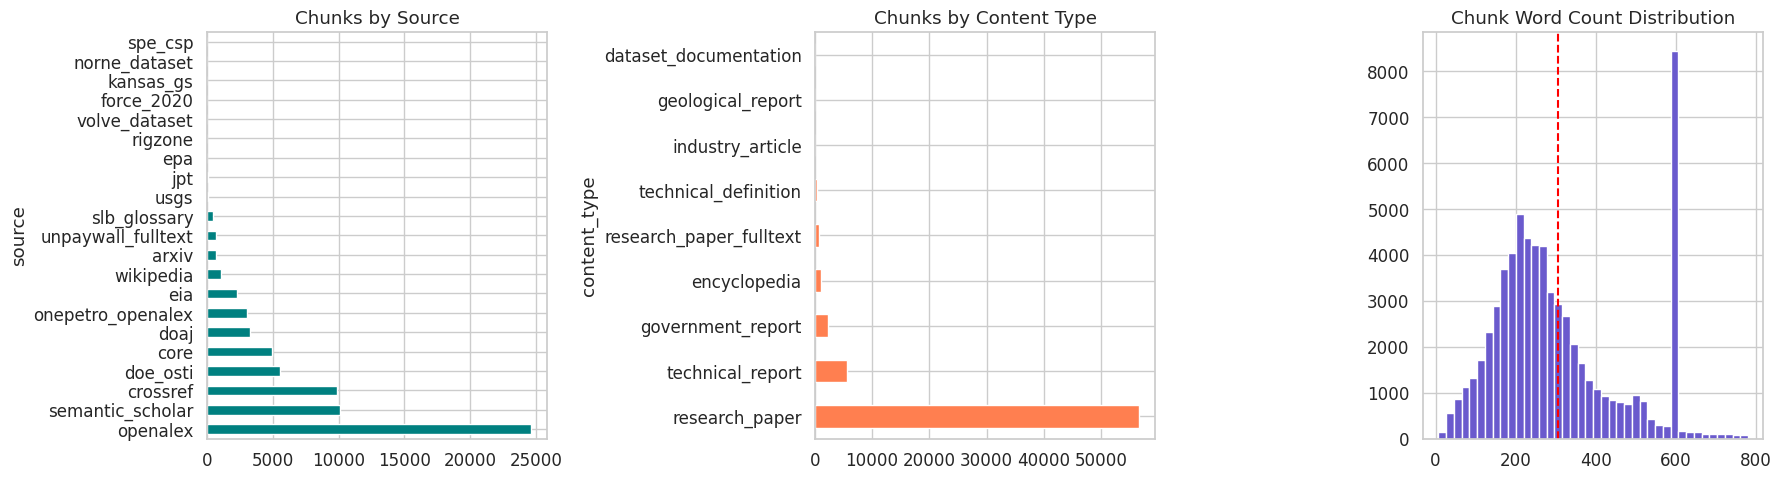

In [ ]:
if len(df_seed) > 0:
    print("SEED CORPUS OVERVIEW")
    print("=" * 60)
    print(f"  Total chunks: {len(df_seed):,}")
    print(f"  Columns: {list(df_seed.columns)}")

    if 'word_count' in df_seed.columns:
        print(f"  Total words: {df_seed['word_count'].sum():,}")
        print(f"  Avg chunk:   {df_seed['word_count'].mean():.0f} words")

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    if 'source' in df_seed.columns:
        df_seed['source'].value_counts().plot.barh(ax=axes[0], color='teal')
        axes[0].set_title('Chunks by Source')

    if 'content_type' in df_seed.columns:
        df_seed['content_type'].value_counts().plot.barh(ax=axes[1], color='coral')
        axes[1].set_title('Chunks by Content Type')

    if 'word_count' in df_seed.columns:
        axes[2].hist(df_seed['word_count'], bins=40, color='slateblue', edgecolor='white')
        axes[2].set_title('Chunk Word Count Distribution')
        axes[2].axvline(df_seed['word_count'].mean(), color='red', ls='--')

    plt.tight_layout(); plt.show()
else:
    print("Seed corpus not available.")

---
## 9. Potential Issues & Data Health

In [ ]:
print("DATA HEALTH CHECK")
print("=" * 60)

# 1. Very short responses
short_resp = df[df['resp_words'] < 30]
print(f"\n1. Very short responses (<30 words): {len(short_resp):,} ({100*len(short_resp)/len(df):.1f}%)")
if len(short_resp) > 0:
    print(f"   Sample: {short_resp.iloc[0]['instruction'][:80]}...")

# 2. Very long responses
long_resp = df[df['resp_words'] > 800]
print(f"2. Very long responses (>800 words):  {len(long_resp):,} ({100*len(long_resp)/len(df):.1f}%)")

# 3. Duplicate instructions
dup_instr = df['instruction'].duplicated().sum()
print(f"3. Duplicate instructions: {dup_instr:,}")

# 4. Near-duplicate instructions (first 50 chars match)
df['instr_prefix'] = df['instruction'].str[:50].str.lower().str.strip()
near_dup = df['instr_prefix'].duplicated().sum()
print(f"4. Near-duplicate instructions (50-char prefix): {near_dup:,}")

# 5. Response starts with preamble
preambles = ['Sure', 'Of course', 'Great question', 'Certainly', "I'd be happy", 'Here is', 'Here are']
has_preamble = df['response'].apply(lambda x: any(str(x).startswith(p) for p in preambles))
print(f"5. Responses with chatbot preamble: {has_preamble.sum():,} ({100*has_preamble.mean():.1f}%)")

# 6. Empty or whitespace-only
empty_instr = (df['instruction'].str.strip() == '').sum()
empty_resp  = (df['response'].str.strip() == '').sum()
print(f"6. Empty instructions: {empty_instr}  |  Empty responses: {empty_resp}")

# 7. Non-English check (simple heuristic)
#non_ascii = df['response'].str.contains(r'[]{10,}', regex=True, na=False).sum()
#print(f"7. Responses with 10+ consecutive non-ASCII chars: {non_ascii}")

# 8. Token budget (for fine-tuning)
over_2k = (df['est_tokens'] > 2048).sum()
over_4k = (df['est_tokens'] > 4096).sum()
print(f"8. Samples >2048 est. tokens: {over_2k:,} | >4096: {over_4k:,}")

df.drop(columns=['instr_prefix'], inplace=True)

print(f"\nOVERALL: {'HEALTHY' if dup_instr < 100 and empty_instr == 0 and empty_resp == 0 else 'NEEDS ATTENTION'}")

DATA HEALTH CHECK

1. Very short responses (<30 words): 219 (0.6%)
   Sample: Analyze the following case study: a 12,000‑ft horizontal well in a low‑permeabil...
2. Very long responses (>800 words):  1 (0.0%)
3. Duplicate instructions: 0
4. Near-duplicate instructions (50-char prefix): 3,734
5. Responses with chatbot preamble: 0 (0.0%)
6. Empty instructions: 0  |  Empty responses: 0
8. Samples >2048 est. tokens: 0 | >4096: 0

OVERALL: HEALTHY


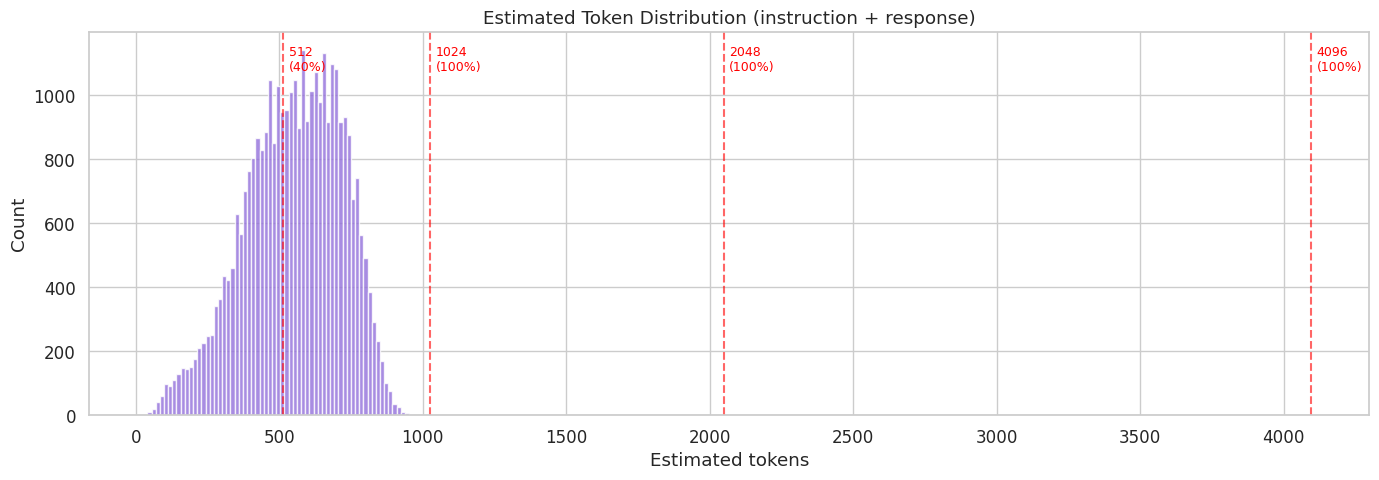

Token budget coverage:
  <=   512: 40.5% of samples
  <=  1024: 100.0% of samples
  <=  2048: 100.0% of samples
  <=  4096: 100.0% of samples
  <=  8192: 100.0% of samples


In [ ]:
# Token distribution for fine-tuning planning
fig, ax = plt.subplots(figsize=(14, 5))
ax.hist(df['est_tokens'], bins=80, color='mediumpurple', edgecolor='white', alpha=0.8)
for threshold in [512, 1024, 2048, 4096]:
    pct = (df['est_tokens'] <= threshold).mean()
    ax.axvline(threshold, color='red', ls='--', alpha=0.6)
    ax.text(threshold+20, ax.get_ylim()[1]*0.9, f'{threshold}\n({100*pct:.0f}%)', fontsize=9, color='red')
ax.set_title('Estimated Token Distribution (instruction + response)')
ax.set_xlabel('Estimated tokens'); ax.set_ylabel('Count')
plt.tight_layout(); plt.show()

print("Token budget coverage:")
for t in [512, 1024, 2048, 4096, 8192]:
    pct = (df['est_tokens'] <= t).mean()
    print(f"  <= {t:>5}: {100*pct:.1f}% of samples")

---
## 10. Sample Gallery - Random Examples

In [ ]:
# Show 5 random high-quality examples
np.random.seed(42)
indices = np.random.choice(len(df), min(5, len(df)), replace=False)

for j, idx in enumerate(indices):
    row = df.iloc[idx]
    print(f"{'='*70}")
    print(f"EXAMPLE {j+1}")
    if 'instruction_category' in df.columns and pd.notna(row.get('instruction_category')):
        print(f"Category: {row['instruction_category']}  |  ", end="")
    if 'complexity_level' in df.columns and pd.notna(row.get('complexity_level')):
        print(f"Complexity: {row['complexity_level']}  |  ", end="")
    if 'subdomain' in df.columns and pd.notna(row.get('subdomain')):
        print(f"Subdomain: {row['subdomain']}", end="")
    print()
    print(f"{'='*70}")
    print(f"\nINSTRUCTION ({row['instr_words']:.0f} words):")
    print(row['instruction'][:500])
    print(f"\nRESPONSE ({row['resp_words']:.0f} words):")
    print(row['response'][:800])
    if len(str(row['response'])) > 800: print("...")
    print()

EXAMPLE 1


INSTRUCTION (26 words):
What repair strategy does the paper propose for an ESP when a cable failure is identified close to the surface, and how is this strategy implemented?

RESPONSE (538 words):
**Repair Strategy – “Surface‑Proximate Cable‑Only Re‑Landing”**

The paper’s preferred remedy for a cable fault that is detected ≤ ~30 m (≈ 100 ft) from the wellhead is to **re‑land the ESP in‑situ without removing the motor or performing a full teardown**. In practice the approach is executed as a *cable‑only replacement* (sometimes called a “non‑serviced motor rerun”). The key steps are:

1. **Fault Localization and Verification**  
   * Down‑hole pressure and motor‑current telemetry are examined in real time. A sudden rise in motor current or a voltage dip that correlates with a known cable‑fault signature (e.g., increased resistance on a specific phase) triggers a surface‑based diagnostic.  
   * A quick “cable‑pulse” test—applying a short high‑frequency voltage pulse down the

---
## 11. Summary Dashboard

In [ ]:
# Final summary
sep = '=' * 70
print(sep); print("NAIJA-PETRO DATASET - EDA SUMMARY"); print(sep)
print(f"\nDATASET SIZE")
print(f"  Total samples:          {len(df):,}")
print(f"  Total words:            {(df['instr_words'].sum()+df['resp_words'].sum()):,}")
print(f"  Estimated tokens:       {df['est_tokens'].sum():,}")
print(f"\nINSTRUCTIONS")
print(f"  Avg words:              {df['instr_words'].mean():.0f}")
print(f"  Median words:           {df['instr_words'].median():.0f}")
print(f"  Questions (?):          {100*df['instr_is_question'].mean():.0f}%")
print(f"\nRESPONSES")
print(f"  Avg words:              {df['resp_words'].mean():.0f}")
print(f"  Median words:           {df['resp_words'].median():.0f}")
print(f"  Has equations:          {100*df['resp_has_equation'].mean():.0f}%")
print(f"  Has engineering units:  {100*df['resp_has_units'].mean():.0f}%")
print(f"  Has numeric values:     {100*df['resp_has_numbers'].mean():.0f}%")
print(f"\nDIVERSITY")
print(f"  Unique instructions:    {df['instruction'].nunique():,}")
if 'instruction_category' in df.columns: print(f"  Categories:             {df['instruction_category'].nunique()}")
if 'subdomain' in df.columns: print(f"  Subdomains:             {df['subdomain'].nunique()}")
if 'complexity_level' in df.columns: print(f"  Complexity levels:      {df['complexity_level'].nunique()}")
if 'pipeline' in df.columns: print(f"  Pipelines:              {df['pipeline'].nunique()}")
print(f"\nDOMAIN COVERAGE")
print(f"  Petroleum keywords:     {len(kw_present)}/{len(PETRO_KEYWORDS)}")
print(f"  Keyword mentions:       {kw_present.sum():,}")
print(f"\nFINE-TUNING READINESS")
print(f"  Fits 2048 tokens:       {100*(df['est_tokens']<=2048).mean():.0f}%")
print(f"  Fits 4096 tokens:       {100*(df['est_tokens']<=4096).mean():.0f}%")
print(f"  Duplicates:             {dup_instr:,}")
print(f"  Empty records:          {empty_instr + empty_resp}")
print(sep)

NAIJA-PETRO DATASET - EDA SUMMARY

DATASET SIZE
  Total samples:          33,859
  Total words:            13,917,855
  Estimated tokens:       18,545,945

INSTRUCTIONS
  Avg words:              46
  Median words:           40
  Questions (?):          46%

RESPONSES
  Avg words:              365
  Median words:           372
  Has equations:          83%
  Has engineering units:  53%
  Has numeric values:     99%

DIVERSITY
  Unique instructions:    33,859
  Categories:             10
  Subdomains:             12
  Complexity levels:      4

DOMAIN COVERAGE
  Petroleum keywords:     48/48
  Keyword mentions:       607,971

FINE-TUNING READINESS
  Fits 2048 tokens:       100%
  Fits 4096 tokens:       100%
  Duplicates:             0
  Empty records:          0


  NOT TO BE USED
  

In [ ]:
from gradio_client import Client

client = Client("Shinzmann/naija-petro-chat")
result = client.predict(
		message="Hello!!",
		api_name="/chat"
)
print(result)

Loaded as API: https://shinzmann-naija-petro-chat.hf.space ✔


AppError: GPU task aborted

In [ ]:
# ============================================================
# All variables needed for Naija-Petro deployment
# Run this first in any new notebook
# ============================================================
from pathlib import Path
from google.colab import userdata

# HuggingFace
HF_USERNAME       = userdata.get('HF_USERNAME')
HF_MODEL_NAME     = "naija-petro"
HF_REPO_ID        = f"{HF_USERNAME}/{HF_MODEL_NAME}"
HF_GGUF_REPO      = f"{HF_REPO_ID}-GGUF"
HF_SPACE_REPO     = f"{HF_USERNAME}/{HF_MODEL_NAME}-chat"

# Model
BASE_MODEL        = "Qwen/Qwen3-32B"
MAX_SEQ_LENGTH    = 2048
LOAD_IN_4BIT      = True

# LoRA
LORA_R, LORA_ALPHA, LORA_DROPOUT = 64, 128, 0.0

# Training
NUM_EPOCHS        = 2
BATCH_SIZE        = 8
GRAD_ACCUM_STEPS  = 8
LEARNING_RATE     = 2e-4
WARMUP_RATIO      = 0.05
LR_SCHEDULER      = "cosine"
WEIGHT_DECAY      = 0.01
LOGGING_STEPS     = 10
SAVE_STEPS        = 50
EVAL_STEPS        = 100
SEED              = 42
GGUF_QUANTS       = ["q4_k_m", "q5_k_m", "q8_0"]

# Paths
DRIVE_BASE        = Path("/content/drive/MyDrive/petroleum_corpus")
DATASET_PATH      = DRIVE_BASE / "processed" / "final_alpaca_format.jsonl"
OUTPUT_DIR        = str(DRIVE_BASE / "checkpoints" / HF_MODEL_NAME)

# W&B
WANDB_PROJECT, USE_WANDB = "naija-petro", True

# System prompt
SYSTEM_PROMPT = (
    "You are Naija-Petro, an expert petroleum engineering AI assistant. "
    "You provide precise, technically accurate answers covering drilling, "
    "reservoir engineering, production, completions, EOR, well testing, "
    "and petroleum geoscience. Include equations, units, and practical considerations."
)

# Auth
from huggingface_hub import login
login(token=userdata.get('HF_TOKEN'))

print(f"HF Repo     : {HF_REPO_ID}")
print(f"GGUF Repo   : {HF_GGUF_REPO}")
print(f"Space       : {HF_SPACE_REPO}")
print(f"Base Model  : {BASE_MODEL}")
print(f"Drive Base  : {DRIVE_BASE}")
print("✓ All variables defined and authenticated")

HF Repo     : Shinzmann/naija-petro
GGUF Repo   : Shinzmann/naija-petro-GGUF
Space       : Shinzmann/naija-petro-chat
Base Model  : Qwen/Qwen3-32B
Drive Base  : /content/drive/MyDrive/petroleum_corpus
✓ All variables defined and authenticated


In [ ]:
from huggingface_hub import HfApi

app_code = f'''import gradio as gr
import spaces
import os
from llama_cpp import Llama
from huggingface_hub import hf_hub_download

MODEL_REPO = "{HF_GGUF_REPO}"
MODEL_FILE = "Qwen3-32B.Q4_K_M.gguf"
SYSTEM = "{SYSTEM_PROMPT}"

# Download GGUF at startup (CPU, cached to disk)
print(f"Downloading {{MODEL_FILE}}...")
model_path = hf_hub_download(
    repo_id=MODEL_REPO,
    filename=MODEL_FILE,
    token=os.environ.get("HF_TOKEN"),
)
print(f"Model downloaded to {{model_path}}")

# Load on CPU at startup — mmap keeps RAM low
llm = Llama(
    model_path=model_path,
    n_ctx=2048,
    n_threads=8,
    n_gpu_layers=0,
    use_mmap=True,
    verbose=False,
)
print("Model loaded on CPU!")

def respond(message, history):
    messages = [{{"role": "system", "content": SYSTEM}}]
    for msg in history:
        messages.append(msg)
    messages.append({{"role": "user", "content": message}})

    response = llm.create_chat_completion(
        messages=messages,
        max_tokens=512,
        temperature=0.4,
        top_p=0.9,
        repeat_penalty=1.1,
    )

    return response["choices"][0]["message"]["content"]

EXAMPLES = [
    "Explain the material balance equation for an undersaturated reservoir.",
    "What are the screening criteria for CO2 EOR?",
    "How do you interpret a Horner plot?",
    "Compare ESP vs gas lift for artificial lift.",
    "What causes water coning and how to mitigate it?",
]

demo = gr.ChatInterface(
    fn=respond,
    title="Naija-Petro -- Petroleum Engineering AI",
    description="Petroleum engineering AI powered by Qwen3-32B fine-tuned for petroleum engineering. Responses may take 30-90s.",
    examples=EXAMPLES,
    theme=gr.themes.Soft(),
    type="messages",
    cache_examples=False,
)

if __name__ == "__main__":
    demo.launch()
'''

requirements = """gradio>=5.0.0
llama-cpp-python
huggingface_hub
"""

api = HfApi()
for name, content in [
    ("app.py", app_code),
    ("requirements.txt", requirements),
]:
    api.upload_file(
        path_or_fileobj=content.encode(),
        path_in_repo=name,
        repo_id=HF_SPACE_REPO,
        repo_type="space"
    )
    print(f"Uploaded {name}")

print(f"\nSpace rebuilding: https://huggingface.co/spaces/{HF_SPACE_REPO}")

Uploaded app.py
Uploaded requirements.txt

Space rebuilding: https://huggingface.co/spaces/Shinzmann/naija-petro-chat
